In [ ]:
!pip install sentence-transformers
!pip install torch torchvision
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 99.0 MB/s eta 0:00:00


In [1]:
import pandas as pd

df = pd.read_csv("products.csv")

print(df.head())

print(df.columns)

   product_id         brand  \
0  B08YRWN3WB      JANSPORT   
1  B08YRXFZZM      JANSPORT   
2  B09Q2PQ7ZB       BAODINI   
3  B001BEAWXY  Calvin Klein   
4  B09FM5PMN3      JANSPORT   

                                               title   price    category  \
0  Big Student Large laptop backpack Black EK0A5B...  189.00  New season   
1                                Superbreak Day Pack  119.00  New season   
2  Mini Travel Umbrella With Case Small Compact U...   17.79  New season   
3           Men's Cotton Classics 3-Pack Boxer Brief  119.00  New season   
4                           Unisex Kids Bag Backpack  179.00  New season   

   rating                                          image_url  \
0     4.7  https://m.media-amazon.com/images/I/51y2EF0OmO...   
1     4.6  https://m.media-amazon.com/images/I/51yvvQUs3S...   
2     4.2  https://m.media-amazon.com/images/I/71WbrZPbnG...   
3     4.2  https://m.media-amazon.com/images/I/716vzeqa7Z...   
4     4.4  https://m.media-amazon.co

In [2]:
print(df.columns)

Index(['product_id', 'brand', 'title', 'price', 'category', 'rating',
       'image_url', 'product_url'],
      dtype='object')


In [3]:
print(df.shape)

(13156, 8)


In [4]:
df.isnull().sum()

,0
product_id,0
brand,1
title,1
price,193
category,0
rating,883
image_url,0
product_url,0


In [5]:
df["brand"] = df["brand"].fillna("Unknown")
df["title"] = df["title"].fillna("Unknown")


In [6]:
df["price"] = df["price"].fillna(df["price"].median())
df["rating"] = df["rating"].fillna(df["rating"].median())


In [7]:
df.duplicated().sum()

np.int64(667)

In [8]:
df = df.drop_duplicates()

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df["title"] = df["title"].str.strip()

In [11]:
df["title"] = df["title"].str.lower()

In [12]:
print(df.shape)

(12489, 8)


In [13]:
import re

def clean_text(text):
    text = re.sub(r'[^a-zA-Z0-9 ]', '', str(text))
    return text

df["title"] = df["title"].apply(clean_text)

In [14]:
print(df["brand"].nunique())

2409


In [15]:
print(df["brand"].value_counts().head())

brand
Casio             484
adidas            478
Skechers          436
Nike              288
Tommy Hilfiger    251
Name: count, dtype: int64


In [16]:
df.isnull().sum()

,0
product_id,0
brand,0
title,0
price,0
category,0
rating,0
image_url,0
product_url,0


In [17]:
df["combined_text"] = (
    df["brand"] + " " +
    df["title"] + " " +
    df["category"]
)

In [ ]:
df.to_csv("cleaned_amazon_fashion.csv", index=False)

In [18]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [19]:
text_embeddings = model.encode(
    df["combined_text"].tolist(),
    show_progress_bar=True
)

Batches:   0%|          | 0/391 [00:00<?, ?it/s]

In [20]:
print(text_embeddings.shape)

(12489, 384)


In [21]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

df["brand_encoded"] = le.fit_transform(df["brand"])

In [22]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df["price_scaled"] = scaler.fit_transform(
    df[["price"]]
)

In [23]:
import numpy as np

brand_feature = df["brand_encoded"].values.reshape(-1,1)
price_feature = df["price_scaled"].values.reshape(-1,1)

In [24]:
final_features = np.hstack([
    text_embeddings,
    brand_feature,
    price_feature
])

In [25]:
print(final_features.shape)

(12489, 386)


In [26]:
from sklearn.preprocessing import normalize

final_features = normalize(final_features)

In [27]:
#similarity check with text,brand,price
from sklearn.metrics.pairwise import cosine_similarity
query = final_features[10].reshape(1, -1)

In [28]:
similarities = cosine_similarity(
    query,
    final_features
)

In [29]:
print(similarities.shape)

(1, 12489)


In [30]:
import numpy as np

similar_indices = np.argsort(
    similarities[0]
)[::-1]

In [31]:
print(similar_indices[:5])

[  10   18 5087   27  132]


In [32]:
def recommend(product_index, top_n=5):

    query = final_features[
        product_index
    ].reshape(1,-1)

    similarities = cosine_similarity(
        query,
        final_features
    )

    similar_products = np.argsort(
        similarities[0]
    )[::-1]

    recommendations = similar_products[
        1:top_n+1
    ]

    return recommendations

In [33]:
recommendations = recommend(10)

In [34]:
for idx in recommendations:

    print(
        df.iloc[idx]["title"]
    )

unisex elmntl  hbr backpack
mens elmntl  lbr backpack
unisex elmntl prm backpack
unisex nk elmntl prm bkpk backpack
mens air grx backpack


In [36]:
!pip install faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 87.0 MB/s eta 0:00:00


In [37]:
#FAISS vector search library sys from meta
import faiss
dimension = final_features.shape[1]

index = faiss.IndexFlatIP(
    dimension
)

In [38]:
index.add(
    final_features.astype(
        "float32"
    )
)

In [39]:
print(index.ntotal)

12489


In [40]:
query = final_features[
    10
].reshape(1,-1)

In [41]:
scores, indices = index.search(
    query.astype("float32"),
    6
)
print(scores)
print(indices)

[[1.         1.         1.         1.         0.99999994 0.99999994]]
[[5087   27   18   10  133  132]]


In [42]:
for idx in indices[0][1:]:

    print(
        df.iloc[idx]["title"]
    )
print("--------")
print(df.iloc[10]["title"])

unisex elmntl prm backpack
unisex elmntl  hbr backpack
mens elmntl  lbr backpack
mens air grx backpack
unisex nk elmntl prm bkpk backpack
--------
mens elmntl  lbr backpack


In [43]:
#multimodal ie moving text recommendation to image recommendation
from torchvision import models
import torch

resnet = models.resnet50(
    pretrained=True
)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 232MB/s]


In [44]:
resnet.fc = torch.nn.Identity()
resnet.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [45]:
import requests
from PIL import Image
from io import BytesIO

In [46]:
url = df.loc[0, "image_url"]

In [47]:
response = requests.get(url)
image = Image.open(
    BytesIO(response.content)
)

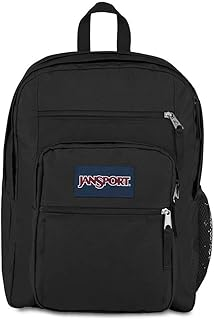

In [48]:
image

In [49]:
from torchvision import transforms
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

In [50]:
image_tensor = transform(
    image
)

In [51]:
print(image_tensor.shape)

torch.Size([3, 224, 224])


In [52]:
image_tensor = image_tensor.unsqueeze(0)

In [53]:
#generate embedding
with torch.no_grad():

    embedding = resnet(
        image_tensor
    )

In [54]:
print(
    embedding.shape
)

torch.Size([1, 2048])


In [55]:
embedding = (
    embedding
    .squeeze()
    .numpy()
)

In [56]:
print(
    embedding.shape
)

(2048,)


In [57]:
def image_embedding_from_url(url):

    try:

        response = requests.get(
            url,
            timeout=10
        )

        image = Image.open(
            BytesIO(response.content)
        ).convert("RGB")

        image_tensor = transform(
            image
        ).unsqueeze(0)

        with torch.no_grad():

            embedding = resnet(
                image_tensor
            )

        return (
            embedding
            .squeeze()
            .numpy()
        )

    except:

        return np.zeros(2048)

In [58]:
emb = image_embedding_from_url(
    df.loc[0,"image_url"]
)

In [59]:
print(emb.shape)

(2048,)


In [60]:
image_embeddings = []

for url in df["image_url"][:100]:

    emb = image_embedding_from_url(
        url
    )

    image_embeddings.append(
        emb
    )

In [61]:
image_embeddings = np.array(
    image_embeddings
)

In [62]:
print(
    image_embeddings.shape
)

(100, 2048)


In [63]:
text_emb_100  = text_embeddings[:100]
brand_emb_100 = brand_feature[:100]
price_emb_100 = price_feature[:100]

print(text_emb_100.shape)
print(brand_emb_100.shape)
print(price_emb_100.shape)
print(image_embeddings.shape)

(100, 384)
(100, 1)
(100, 1)
(100, 2048)


In [64]:
import numpy as np

final_features = np.hstack([
    text_emb_100,
    brand_emb_100,
    price_emb_100,
    image_embeddings
])

In [65]:
print(final_features.shape)

(100, 2434)


In [66]:
from sklearn.preprocessing import normalize

final_features = normalize(
    final_features,
    norm='l2'
)

In [67]:
from sklearn.metrics.pairwise import cosine_similarity
similarity_matrix = cosine_similarity(
    final_features
)

In [68]:
def recommend(product_idx, top_n=5):

    similarities = similarity_matrix[
        product_idx
    ]

    similar_products = np.argsort(
        similarities
    )[::-1]

    return similar_products[1:top_n+1]

In [69]:
indices = recommend(0)

print("Selected Product:")
print(df.iloc[0]["title"])

print("\nRecommendations:")

for idx in indices:

    print(df.iloc[idx]["title"])

Selected Product:
big student large laptop backpack black ek0a5bahn551

Recommendations:
unisex kids bag backpack
unisex big day pack backpacks
unisexadult main campus backpack
superbreak backpack
large accessory pouch  secure storage space for pens power cords pencil case ideal for everyday need 13l navy


In [75]:
from IPython.display import display, HTML

indices = recommend(1)

html = "<h3>Selected Product</h3>"
html += f"""
<div style='display:inline-block; margin:10px; text-align:center;'>
    <img src="{df.iloc[1]['image_url']}" width="200"><br>
    <b>{df.iloc[1]['title']}</b>
</div>
"""

html += "<h3>Recommendations</h3>"

for idx in indices:
    html += f"""
    <div style='display:inline-block; margin:10px; text-align:center; vertical-align:top;'>
        <img src="{df.iloc[idx]['image_url']}" width="200"><br>
        <span>{df.iloc[idx]['title']}</span>
    </div>
    """

display(HTML(html))